In [1]:
from mldb.store import RunStore
import seaborn as sns

sns.set_theme("paper", "whitegrid")

Initialize store

In [2]:
store = RunStore("../../../data")

Analyze results using duckdb and sql

In [3]:
store.list_runs(tags=["model", "german"])

[RunInfo(run_id='run_2026-07-26-15:47:24_46178779_awesome_proskuriakova', run_name='awesome_proskuriakova', run_timestamp='2026-07-26 15:47:24', tags=['german', 'logreg', 'model'], hparams=['l1_ratio=0.5', 'solver=saga']),
 RunInfo(run_id='run_2026-07-26-15:47:24_db73bc16_sharp_chatterjee', run_name='sharp_chatterjee', run_timestamp='2026-07-26 15:47:24', tags=['german', 'model', 'xgboost'], hparams=['eval_metric=logloss'])]

In [4]:
store.list_artifacts_by_query(tags=["model", "german"])

[ArtifactInfo(run_id='run_2026-07-26-15:47:24_46178779_awesome_proskuriakova', artifact_name='predictions_test', artifact_checksum='0da63c6e55aa56161e468ec19d19a30cb123e5f60b6117f6d58b357e1d6295a7_table_200_3'),
 ArtifactInfo(run_id='run_2026-07-26-15:47:24_46178779_awesome_proskuriakova', artifact_name='predictions_train', artifact_checksum='50557249a501bf4ef71b28e0f035703c5647cf7d6f3c19dd9e258580b8bdb887_table_800_3'),
 ArtifactInfo(run_id='run_2026-07-26-15:47:24_db73bc16_sharp_chatterjee', artifact_name='predictions_test', artifact_checksum='441f295d57d0d03baf33b51f11ca1b1a2a87f285b21fa33d25534799c5f370ad_table_200_3'),
 ArtifactInfo(run_id='run_2026-07-26-15:47:24_db73bc16_sharp_chatterjee', artifact_name='predictions_train', artifact_checksum='1ba60d081c642490e6a8b12afa4e042bb6fc53fd1244dfaf0294f732c9b47ce5_table_800_3')]

<Axes: xlabel='personal_status_sex', ylabel='accuracy'>

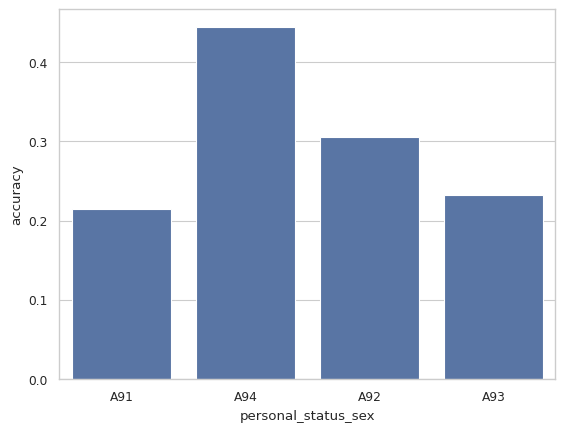

In [5]:
db = store.get_db()
db.attach(names=["predictions_test"], tags=["model", "german"])
db.attach(names=["german"])
with db.connect() as con:
    sql_result = con.sql(
        """
        select personal_status_sex, avg(case when y_true != predictions then 1 else 0 end) as accuracy
        from predictions_test p
        join german d
        on p.uuid=d.uuid
        group by personal_status_sex
        """
    ).df()
sns.barplot(sql_result, x="personal_status_sex", y="accuracy")

Analyze results in pandas

In [7]:
store.load_artifacts_by_query(names=["predictions_test"], tags=["model", "german"])

[StoredArtifact(run_id='run_2026-07-26-15:47:24_46178779_awesome_proskuriakova', artifact_name='predictions_test', artifact=                                     uuid  y_true  predictions
 0    68d47637-59a7-4268-ad70-0dd465d3c90d       0            0
 1    ea5c7841-2cdd-4605-ad4a-623023123303       0            0
 2    2b507117-3a8e-45f3-8fcc-cb915eb9e903       0            0
 3    eb975ef0-021f-4dad-b165-6db0e36da0ca       0            0
 4    3bd41426-2f98-48a9-b7c0-1094209af9a1       0            0
 ..                                    ...     ...          ...
 195  29c3bcb8-6180-4e48-a7aa-9f9815d4bcc9       0            0
 196  23ec7b87-0f65-4312-8beb-cb671a99f46f       1            0
 197  9cb82491-f81e-4484-86ca-9b60bbab8a1e       0            0
 198  8dc44c31-0e78-4e2d-be75-1276a5e43abc       1            0
 199  d95b7c41-ad67-47c6-ab9e-2e6dfeddba34       0            0
 
 [200 rows x 3 columns]),
 StoredArtifact(run_id='run_2026-07-26-15:47:24_db73bc16_sharp_chatterjee', artif

In [ ]:
pd_df = store.load_artifact_by_query(
    name="predictions", tags=["example_run_1", "german"]
)
ge_df = store.load_artifact_by_query(name="german")
pd_result = pd_df.merge(ge_df, on="uuid")[pd_df["y_true"] != pd_df["predictions"]]
print(pd_result.columns)

Index(['uuid', 'y_true', 'predictions', 'status', 'duration', 'credit_history',
       'purpose', 'credit_amount', 'savings', 'employment_since',
       'installment_rate', 'personal_status_sex', 'other_debtors',
       'residence_since', 'property', 'age', 'other_installment_plans',
       'housing', 'existing_credits', 'job', 'num_dependents', 'telephone',
       'foreign_worker', 'credit_risk'],
      dtype='str')
